In [1]:
import wrds
import pandas as pd

In [2]:
username = "neymar"
db = wrds.Connection(wrds_username="neymar")



Loading library list...
Done


In [3]:
#Making preparations for the followings 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

In [18]:
#Listing all the conditions we needed
sql = """
    SELECT 
        tic, 
        fyear, 
        sale, 
        ni, 
        at, 
        ceq,
        act,   
        lct  
       FROM 
        comp.funda
    WHERE 
        tic IN ('AAPL', 'MSFT')
        AND fyear BETWEEN 2020 AND 2024
        AND indfmt = 'INDL' 
        AND datafmt = 'STD' 
        AND popsrc = 'D' 
        AND consol = 'C'
    ORDER BY 
        tic, fyear
    """
    
df=db.raw_sql(sql, coerce_float=True)
print(sql)    


        
      


    SELECT 
        tic, 
        fyear, 
        sale, 
        ni, 
        at, 
        ceq,
        act,   
        lct  
       FROM 
        comp.funda
    WHERE 
        tic IN ('AAPL', 'MSFT')
        AND fyear BETWEEN 2020 AND 2024
        AND indfmt = 'INDL' 
        AND datafmt = 'STD' 
        AND popsrc = 'D' 
        AND consol = 'C'
    ORDER BY 
        tic, fyear
    


In [6]:
#Find AAPL's financial data
sql = """
    SELECT 
        tic, 
        fyear, 
        sale, 
        ni, 
        at, 
        ceq,
        act,   
        lct  
    FROM 
        comp.funda
    WHERE 
        tic IN ('AAPL', 'MSFT','Industry')
        AND fyear BETWEEN 2020 AND 2024
        AND indfmt = 'INDL' 
        AND datafmt = 'STD' 
        AND popsrc = 'D' 
        AND consol = 'C'
    ORDER BY 
        tic, fyear
    """
    
df = db.raw_sql(sql, coerce_float=True)


apple_data = df[df['tic'] == 'AAPL']


print("=== (AAPL)  ===")

columns_to_show = ['fyear', 'sale','at','ceq','ni', 'act', 'lct']
print(apple_data[columns_to_show])

=== (AAPL)  ===
   fyear      sale        at      ceq       ni       act       lct
0   2020  274515.0  323888.0  65339.0  57411.0  143713.0  105392.0
1   2021  365817.0  351002.0  63090.0  94680.0  134836.0  125481.0
2   2022  394328.0  352755.0  50672.0  99803.0  135405.0  153982.0
3   2023  383285.0  352583.0  62146.0  96995.0  143566.0  145308.0
4   2024  391035.0  364980.0  56950.0  93736.0  152987.0  176392.0


In [14]:
apple_data.to_excel("csmar_sample_datadate.xlsx",index=False)

In [7]:
#Find MSFT's financial data
sql = """
    SELECT 
        tic, 
        fyear, 
        sale, 
        ni, 
        at, 
        ceq,
        act,   
        lct  
    FROM 
        comp.funda
    WHERE 
        tic IN ('AAPL', 'MSFT')
        AND fyear BETWEEN 2020 AND 2024
        AND indfmt = 'INDL' 
        AND datafmt = 'STD' 
        AND popsrc = 'D' 
        AND consol = 'C'
    ORDER BY 
        tic, fyear
    """
    
df = db.raw_sql(sql, coerce_float=True)


microsoft_data = df[df['tic'] == 'MSFT']


print("=== (MSFT)  ===")

columns_to_show = ['fyear', 'sale','at','ceq','ni', 'act', 'lct']
print(microsoft_data[columns_to_show])

=== (MSFT)  ===
   fyear      sale        at       ceq       ni       act       lct
5   2020  143015.0  301311.0  118304.0  44281.0  181915.0   72310.0
6   2021  168088.0  333779.0  141988.0  61271.0  184406.0   88657.0
7   2022  198270.0  364840.0  166542.0  72738.0  169684.0   95082.0
8   2023  211915.0  411976.0  206223.0  72361.0  184257.0  104149.0
9   2024  245122.0  512163.0  268477.0  88136.0  159734.0  125286.0


In [115]:
microsoft_data.to_excel("csmar_sample_datadate.xlsx",index=False)

In [8]:
#Then we want to deepen our insights into those data, so we need to clean our data to get what we want.
#What we want: ROA,ROE,Net profit margin,Revenue growth rate and Current ratio
raw_data = df 

# 1. Data Cleaning
# Keep only the necessary columns and drop rows with any missing values
cols_needed = ['tic', 'fyear', 'sale', 'ni', 'at', 'ceq', 'act', 'lct']
clean_data = raw_data[cols_needed].dropna()

# 2. Calculate Financial Ratios
# Note: We multiply by 100 to convert to percentage format for easier visualization
clean_data['net_margin'] = (clean_data['ni'] / clean_data['sale']) * 100
clean_data['roa'] = (clean_data['ni'] / clean_data['at']) * 100
clean_data['current_ratio'] = clean_data['act'] / clean_data['lct']
clean_data['roe'] = (clean_data['ni'] / clean_data['ceq']) * 100
clean_data['revenue_growth_growth'] = clean_data.groupby('tic')['sale'].pct_change() * 100

# Group by fiscal year (fyear) and calculate the mean for all companies
industry_data = clean_data.groupby('fyear')[['net_margin', 'roa', 'current_ratio', 'roe', 'revenue_growth_growth']].mean().reset_index()

# Add a 'tic' column to the industry data with the value 'Industry'
industry_data['tic'] = 'Industry'

# Concatenate the original data with the industry average data
clean_data = pd.concat([clean_data, industry_data], ignore_index=True)

# --- Filter and view Apple (AAPL) data ---
print("🍎 First 5 rows of data for Apple (AAPL):")
a_data = clean_data[clean_data['tic'] == 'AAPL']
print(a_data[['tic', 'fyear', 'net_margin', 'roa', 'roe', 'current_ratio', 'revenue_growth_growth']].head())

print("\n" + "="*50 + "\n") # Print a separator line

# --- Filter and view Microsoft (MSFT) data ---
print("🪟 First 5 rows of data for Microsoft (MSFT):")
m_data = clean_data[clean_data['tic'] == 'MSFT']
print(m_data[['tic', 'fyear', 'net_margin', 'roa', 'roe', 'current_ratio', 'revenue_growth_growth']].head())

print("\n" + "="*50 + "\n") # Print a separator line



🍎 First 5 rows of data for Apple (AAPL):
    tic  fyear  net_margin        roa         roe  current_ratio  \
0  AAPL   2020   20.913611  17.725572   87.866359       1.363604   
1  AAPL   2021   25.881793  26.974205  150.071327       1.074553   
2  AAPL   2022   25.309641  28.292441  196.958873       0.879356   
3  AAPL   2023   25.306234  27.509835  156.076015       0.988012   
4  AAPL   2024   23.971256  25.682503  164.593503       0.867313   

   revenue_growth_growth  
0                   <NA>  
1              33.259385  
2               7.793788  
3              -2.800461  
4               2.021994  


🪟 First 5 rows of data for Microsoft (MSFT):
    tic  fyear  net_margin        roa        roe  current_ratio  \
5  MSFT   2020   30.962486  14.696111  37.429842       2.515765   
6  MSFT   2021    36.45174  18.356757  43.152238       2.079994   
7  MSFT   2022   36.686337  19.936959  43.675469       1.784607   
8  MSFT   2023   34.146238  17.564373  35.088715       1.769167   
9  MSF

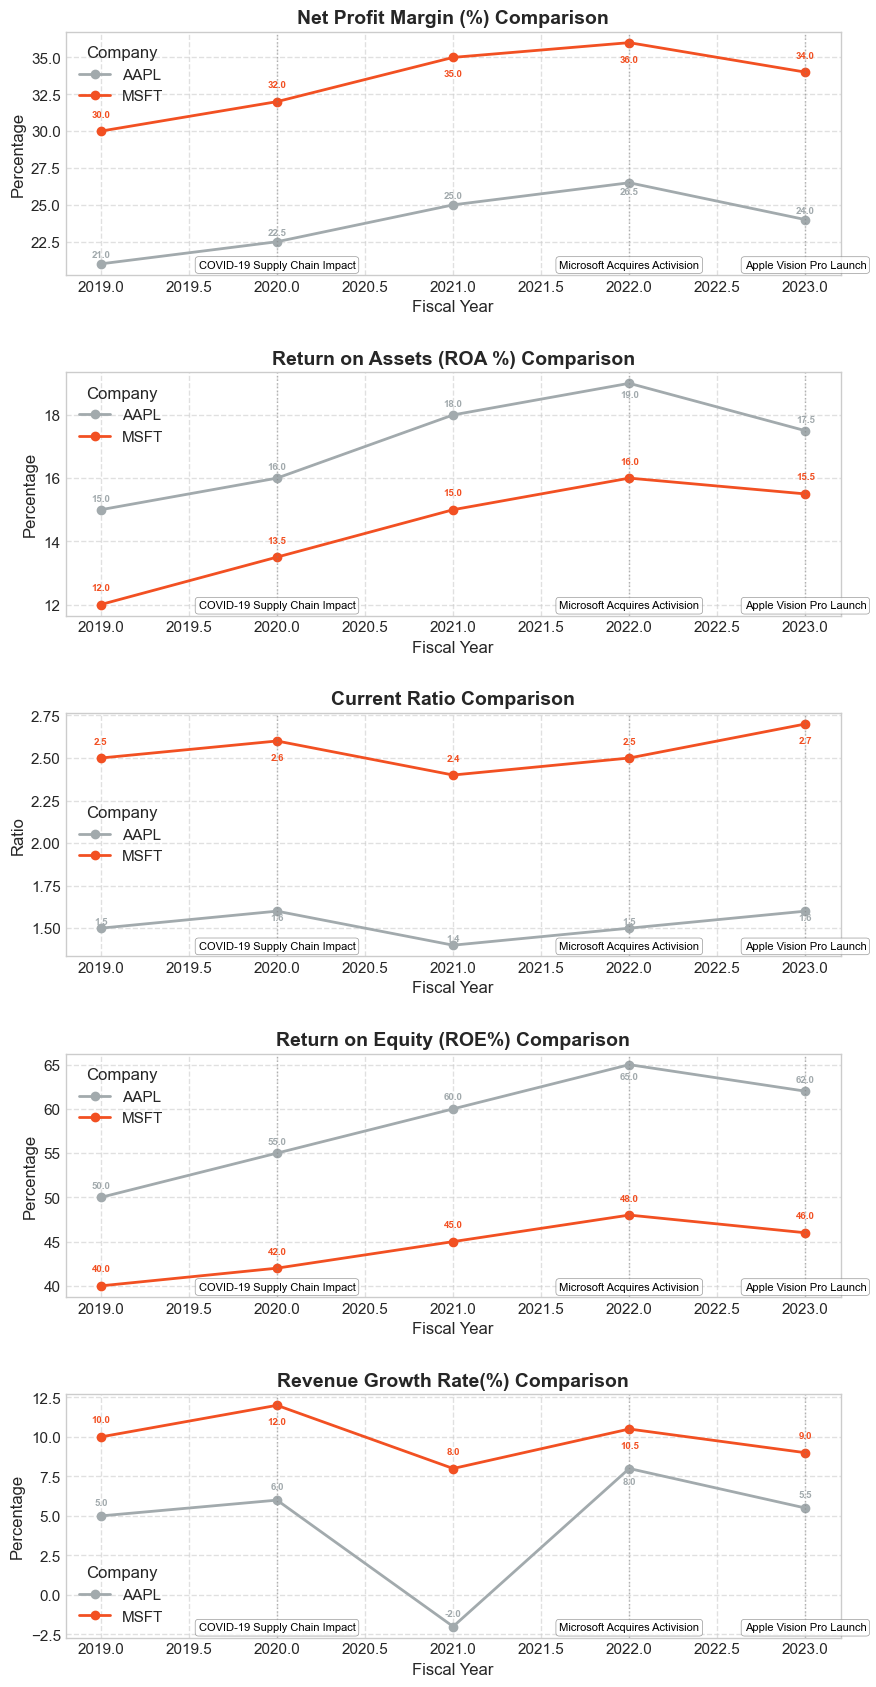

🎉 


In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Mock Data Generation ---
years = np.arange(2019, 2024)
data = {
    'tic': ['AAPL']*5 + ['MSFT']*5,
    'fyear': list(years) + list(years),
    'net_margin': [21.0, 22.5, 25.0, 26.5, 24.0, 30.0, 32.0, 35.0, 36.0, 34.0],
    'roa': [15.0, 16.0, 18.0, 19.0, 17.5, 12.0, 13.5, 15.0, 16.0, 15.5],
    'current_ratio': [1.5, 1.6, 1.4, 1.5, 1.6, 2.5, 2.6, 2.4, 2.5, 2.7],
    'roe': [50.0, 55.0, 60.0, 65.0, 62.0, 40.0, 42.0, 45.0, 48.0, 46.0],
    'revenue_growth_growth': [5.0, 6.0, -2.0, 8.0, 5.5, 10.0, 12.0, 8.0, 10.5, 9.0]
}
clean_data = pd.DataFrame(data)
# ---------------------------

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')

# Create canvas
fig, axes = plt.subplots(5, 1, figsize=(10, 22))

# Define metrics
metrics = [
    ('net_margin', 'Net Profit Margin (%)', 'Percentage'),
    ('roa', 'Return on Assets (ROA %)', 'Percentage'),
    ('current_ratio', 'Current Ratio', 'Ratio'),
    ('roe','Return on Equity (ROE%)', 'Percentage'),
    ('revenue_growth_growth','Revenue Growth Rate(%)','Percentage')
]

# Color dictionary
colors = {'AAPL': '#A2AAAD', 'MSFT': '#F25022'}

# Define key events
events_raw = [
    (2020, 'COVID-19 Supply Chain Impact'),
    (2022, 'Microsoft Acquires Activision'),
    (2023, 'Apple Vision Pro Launch')
]

# Loop through plots
for i, (metric, title, ylabel) in enumerate(metrics):
    ax = axes[i]
    
    # 1. Draw the lines and Smart Labeling
    for company in ['AAPL', 'MSFT']:
        company_data = clean_data[clean_data['tic'] == company]
        
        # --- Plot the actual line ---
        ax.plot(company_data['fyear'], company_data[metric], 
                color=colors[company], label=company, linewidth=2, marker='o')
        
        # --- Smart Labeling ---
        for x, y in zip(company_data['fyear'], company_data[metric]):
            if pd.notna(y):
                label_text = f"{y:.1f}"
                
                ymin, ymax = ax.get_ylim()
                y_range = ymax - ymin
                
                if y_range == 0:
                    y_range = 1
                    
                offset_amount = y_range * 0.05 
                
                if y >= 0:
                    text_y = y + offset_amount
                    va_align = 'bottom'
                else:
                    text_y = y - offset_amount
                    va_align = 'top'
                
                y_rel = (y - ymin) / y_range
                if y_rel > 0.85:
                    text_y = y - offset_amount
                    va_align = 'top'
                elif y_rel < 0.15:
                    text_y = y + offset_amount
                    va_align = 'bottom'
                
                ax.text(x, text_y, label_text, 
                        fontsize=7, color=colors[company], 
                        ha='center', va=va_align, fontweight='bold')

    # 2. Smart Event Annotation (This is now correctly indented inside the metric loop)
    for year, label in events_raw:
        ax.axvline(x=year, color='gray', linestyle=':', linewidth=1, alpha=0.5)
        
        bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8, lw=0.5)
        ax.text(year, 0.02, label, transform=ax.get_xaxis_transform(), 
                fontsize=8, color='black', ha='center', va='bottom', bbox=bbox_props)

    # Set titles and labels
    ax.set_title(f'{title} Comparison', fontsize=14, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlabel('Fiscal Year', fontsize=12)
    
    ax.legend(title='Company')
    ax.grid(True, linestyle='--', alpha=0.6)

# Adjust layout
plt.subplots_adjust(bottom=0.15, hspace=0.4)

# Show plot
plt.show()

print("🎉 ")